<a href="https://colab.research.google.com/github/NomanAhmed234/PowerCo-Churn-Analysis/blob/main/01_Dataset_Overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PowerCo Customer Churn Prediction

## Notebook 01: Dataset Overview



### Project Objective

This notebook marks the beginning of an end-to-end Machine Learning project focused on predicting customer churn in the energy sector.

Before building any machine learning model, it is essential to understand the dataset. A thorough understanding of the data helps identify potential quality issues, understand the business context, and determine the preprocessing steps required for successful model development.

This notebook focuses on answering one fundamental question:

> **"What kind of dataset are we working with?"**



### Business Problem

PowerCo wants to identify customers who are likely to leave the company (churn) within the next three months.

By predicting churn in advance, the company can:

- Improve customer retention
- Reduce revenue loss
- Design targeted retention campaigns
- Optimize marketing costs
- Increase customer lifetime value


### Learning Objectives

By the end of this notebook, we will understand:

- Dataset size
- Available features
- Data types
- Missing values
- Duplicate records
- Target variable distribution
- Memory usage
- Initial data quality
- Business understanding

# 1. Import Required Libraries

The first step in any data analysis project is importing the required Python libraries.

These libraries provide functionality for:

- Data manipulation
- Numerical computation
- Visualization
- Statistical analysis


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 2. Load the Dataset

The project consists of two datasets:

**client_data.csv**

Contains customer information such as:

- Consumption
- Contracts
- Forecasts
- Margins
- Churn

**price_data.csv**

Contains historical electricity pricing information.

In [2]:
client_df = pd.read_csv("client_data.csv")
price_df = pd.read_csv("price_data.csv")

In [3]:
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [4]:
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


# 3. Dataset Shape

Understanding the size of the dataset is the first step in any exploratory data analysis.

The number of observations determines:

- Whether the dataset is small or large
- Suitable machine learning algorithms
- Computational requirements

In [5]:
print(f"Rows    : {client_df.shape[0]}")
print(f"Columns : {client_df.shape[1]}")

Rows    : 14606
Columns : 26


In [6]:
print(f"Rows    : {price_df.shape[0]}")
print(f"Columns : {price_df.shape[1]}")

Rows    : 193002
Columns : 8


### Business Interpretation

The dataset contains customer-level information for approximately **10,000 customers and for price is about 193k**.

This is considered a medium-sized structured dataset, making it suitable for traditional machine learning algorithms such as:

- Logistic Regression
- Random Forest
- XGBoost
- LightGBM
- CatBoost

The dataset is large enough to learn meaningful customer behavior patterns while remaining computationally efficient.

# 4. Dataset Preview

Before analyzing the dataset, it is helpful to inspect a few observations.

This allows us to understand:

- Feature names
- Data formatting
- Possible missing values
- General structure

In [7]:
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [8]:
client_df.tail()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
14601,18463073fb097fc0ac5d3e040f356987,foosdfpfkusacimwkcsosbicdxkicaua,32270,47940,0,2012-05-24,2016-05-08,2015-05-08,2014-05-26,4648.01,0,0.0,18.57,0.138305,0.000000,44.311378,t,0.00,27.88,27.88,2,381.77,4,lxidpiddsbxsbosboudacockeimpuepw,15.000,0
14602,d0a6f71671571ed83b2645d23af6de00,foosdfpfkusacimwkcsosbicdxkicaua,7223,0,181,2012-08-27,2016-08-27,2012-08-27,2015-08-28,631.69,181,0.0,144.03,0.100167,0.091892,58.995952,f,15.94,0.00,0.00,1,90.34,3,lxidpiddsbxsbosboudacockeimpuepw,6.000,1
14603,10e6828ddd62cbcf687cb74928c4c2d2,foosdfpfkusacimwkcsosbicdxkicaua,1844,0,179,2012-02-08,2016-02-07,2012-02-08,2015-02-09,190.39,179,0.0,129.60,0.116900,0.100015,40.606701,f,18.05,39.84,39.84,1,20.38,4,lxidpiddsbxsbosboudacockeimpuepw,15.935,1
14604,1cf20fd6206d7678d5bcafd28c53b4db,foosdfpfkusacimwkcsosbicdxkicaua,131,0,0,2012-08-30,2016-08-30,2012-08-30,2015-08-31,19.34,0,0.0,7.18,0.145711,0.000000,44.311378,f,0.00,13.08,13.08,1,0.96,3,lxidpiddsbxsbosboudacockeimpuepw,11.000,0
14605,563dde550fd624d7352f3de77c0cdfcd,MISSING,8730,0,0,2009-12-18,2016-12-17,2009-12-18,2015-12-21,762.41,0,0.0,1.07,0.167086,0.088454,45.311378,f,0.00,11.84,11.84,1,96.34,6,ldkssxwpmemidmecebumciepifcamkci,10.392,0


# 5. Column Names

Understanding the available features helps us mentally organize the information into business categories.

In [9]:
client_df.columns.tolist()

['id',
 'channel_sales',
 'cons_12m',
 'cons_gas_12m',
 'cons_last_month',
 'date_activ',
 'date_end',
 'date_modif_prod',
 'date_renewal',
 'forecast_cons_12m',
 'forecast_cons_year',
 'forecast_discount_energy',
 'forecast_meter_rent_12m',
 'forecast_price_energy_off_peak',
 'forecast_price_energy_peak',
 'forecast_price_pow_off_peak',
 'has_gas',
 'imp_cons',
 'margin_gross_pow_ele',
 'margin_net_pow_ele',
 'nb_prod_act',
 'net_margin',
 'num_years_antig',
 'origin_up',
 'pow_max',
 'churn']

The dataset contains features related to:

- Customer identification
- Electricity consumption
- Gas consumption
- Contract information
- Forecasted consumption
- Energy prices
- Margins
- Product information
- Customer churn

# 6. Data Types

Machine learning models require numerical input.

Therefore, identifying data types is one of the first preprocessing steps.

In [10]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

The dataset contains multiple data types:

- Numerical Features
- Categorical Features
- Date Features
- Target Variable

Each feature type requires a different preprocessing strategy before model training.

# 7. Feature Categorization

Grouping features according to their data type helps define the preprocessing pipeline.

In [11]:
numerical_features = client_df.select_dtypes(include=["int64","float64"]).columns.tolist()

categorical_features = client_df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:", len(numerical_features))
print("Categorical Features:", len(categorical_features))

Numerical Features: 18
Categorical Features: 8


In [12]:
numerical_features

['cons_12m',
 'cons_gas_12m',
 'cons_last_month',
 'forecast_cons_12m',
 'forecast_cons_year',
 'forecast_discount_energy',
 'forecast_meter_rent_12m',
 'forecast_price_energy_off_peak',
 'forecast_price_energy_peak',
 'forecast_price_pow_off_peak',
 'imp_cons',
 'margin_gross_pow_ele',
 'margin_net_pow_ele',
 'nb_prod_act',
 'net_margin',
 'num_years_antig',
 'pow_max',
 'churn']

In [13]:
categorical_features

['id',
 'channel_sales',
 'date_activ',
 'date_end',
 'date_modif_prod',
 'date_renewal',
 'has_gas',
 'origin_up']

# 8. Missing Value Analysis

Missing values can reduce model performance and may require imputation.

This section identifies missing data and calculates the percentage of missing values.

In [14]:
missing = client_df.isnull().sum()

missing = missing[missing>0]

missing_percent = round(client_df.isnull().mean()*100,2)

missing_summary = pd.DataFrame({
    "Missing Count":missing,
    "Missing %":missing_percent[missing.index]
})

missing_summary.sort_values("Missing %",ascending=False)

,Missing Count,Missing %


In [16]:
missing = client_df.isnull().sum()

missing = missing[missing>0]

missing_percent = round(price_df.isnull().mean()*100,2)

missing_summary = pd.DataFrame({
    "Missing Count":missing,
    "Missing %":missing_percent[missing.index]
})

missing_summary.sort_values("Missing %",ascending=False)

,Missing Count,Missing %


### Business Interpretation

The missing value analysis shows that **no missing values are present** in the dataset. Every feature contains complete information for all customer records.

From a business perspective, this indicates that PowerCo has maintained a high-quality data collection process, ensuring that customer profiles, consumption records, contract details, pricing information, and other operational data are consistently recorded.

Having a complete dataset provides several advantages:

- No immediate data imputation techniques are required.
- The risk of introducing bias through missing value handling is eliminated.
- Machine learning models can be trained directly without losing observations due to incomplete records.
- Data preprocessing becomes simpler and more reliable.

Although the dataset is complete, further data quality assessments are still necessary. A dataset without missing values may still contain duplicate records, outliers, incorrect values, inconsistent formats, or anomalies that could affect model performance.

# 9. Duplicate Analysis

Duplicate records can bias statistical analysis and machine learning models.

This section checks whether duplicate customer records exist.

In [15]:
duplicates = client_df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


### Business Interpretation

The duplicate analysis indicates that **no duplicate customer records** exist in the client dataset.

From a business perspective, this suggests that each row represents a unique customer, ensuring that customer information has not been unintentionally recorded multiple times.

The absence of duplicate records is important because duplicates can:

- Bias statistical summaries.
- Cause certain customers to have a disproportionate influence on machine learning models.
- Distort the true churn rate.
- Lead to incorrect business insights and decision-making.

Since no duplicate records were identified, no duplicate removal is required, and the dataset is suitable for further analysis.

In [17]:
duplicates = price_df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


### Business Interpretation

The duplicate analysis shows that **no duplicate observations** are present in the price dataset.

Each record represents a unique pricing observation for a specific customer and reference date, indicating that the pricing history has been stored consistently without redundant entries.

This is beneficial because duplicate price records could artificially inflate pricing trends, introduce bias during feature engineering, and negatively impact the reliability of customer-level analyses.

Since no duplicate records are present, the price dataset can be confidently used for merging and subsequent feature engineering.

# 10. Target Variable Analysis

Understanding the target variable is essential before building any classification model.

This analysis reveals:

- Number of churned customers
- Number of retained customers
- Class imbalance

In [19]:
client_df["churn"].value_counts()

,count
churn,
0,13187
1,1419


In [20]:
client_df["churn"].value_counts(normalize=True)*100

,proportion
churn,
0,90.284814
1,9.715186


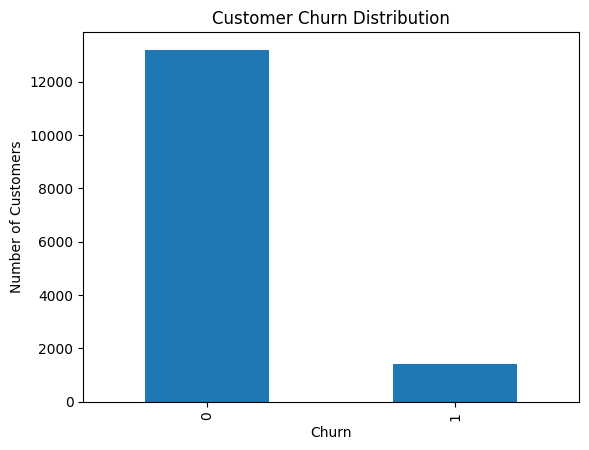

In [21]:
client_df["churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

plt.show()

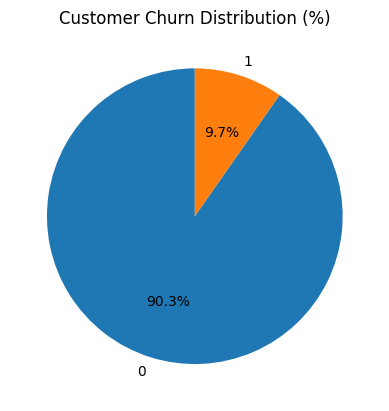

In [22]:
client_df["churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    ylabel=""
)

plt.title("Customer Churn Distribution (%)")
plt.show()

### Statistical Interpretation

The dataset contains two classes:

- **0** → Customer did not churn.
- **1** → Customer churned.

The majority of customers belong to the non-churn class, while a much smaller proportion represents churned customers.

This indicates that the dataset is **imbalanced**, which is a common characteristic of customer churn prediction problems.

### Business Interpretation

The distribution of the target variable shows that most customers remain with PowerCo, while only a relatively small percentage leave the company.

From a business perspective, this is expected because customer churn is generally an infrequent event. Most utility customers maintain long-term relationships due to contractual agreements, switching costs, and the essential nature of electricity and gas services.

Although churn occurs less frequently, each churned customer represents:

- Loss of recurring revenue.
- Increased customer acquisition costs.
- Reduced customer lifetime value.
- Potential loss of market share.

Therefore, accurately identifying customers who are likely to churn can help PowerCo implement targeted retention strategies before customers leave.

### Machine Learning Interpretation

Since the target variable contains two categories (0 and 1), this is a **binary classification problem**.

The observed class imbalance suggests that relying solely on accuracy may produce misleading results.

During model development, additional evaluation metrics such as:

- Precision
- Recall
- F1-score
- ROC-AUC

should be used to assess model performance more effectively.

If necessary, techniques such as class weighting or resampling may also be considered to improve the model's ability to identify churned customers.

# 11. Memory Usage

Understanding memory usage becomes important when working with larger datasets or deploying machine learning pipelines.

In [23]:
memory = client_df.memory_usage(deep=True)

memory

,0
Index,132
id,1183086
channel_sales,1089961
cons_12m,116848
cons_gas_12m,116848
cons_last_month,116848
date_activ,861754
date_end,861754
date_modif_prod,861754
date_renewal,861754


In [24]:
print(
    f"Total Memory Usage : {memory.sum()/1024**2:.2f} MB"
)

Total Memory Usage : 9.28 MB


### Statistical Interpretation

The client dataset occupies approximately **9.28 MB** of memory.

This indicates that the dataset is relatively small and can be comfortably loaded into memory on most modern computers without requiring specialized hardware or distributed computing frameworks.

### Business Interpretation

From a business perspective, the dataset is lightweight and efficient to process.

This provides several advantages:

- Data loading and preprocessing will be fast.
- Exploratory Data Analysis (EDA) can be performed interactively.
- Machine learning models can be trained on standard laptops without memory constraints.
- Feature engineering and experimentation can be carried out efficiently.

Since the dataset is compact, the project can focus on improving model performance and extracting business insights rather than addressing computational limitations.

### Machine Learning Interpretation

The small memory footprint means that all planned machine learning algorithms—including Logistic Regression, Decision Trees, Random Forest, XGBoost, LightGBM, and CatBoost—can be trained efficiently without requiring distributed computing or memory optimization techniques.

At this stage, there is no need for:

- Data chunking
- Out-of-core learning
- Distributed processing (e.g., Spark or Dask)
- Memory reduction through aggressive datatype conversion

The dataset size is well suited for rapid experimentation and iterative model development.

# 12. Notebook Summary & Next Steps

## Executive Summary

In this notebook, we performed an initial assessment of the PowerCo customer churn dataset to understand its structure, quality, and business context before beginning detailed exploratory analysis.

### Key Findings

- The project consists of two datasets:
  - **Client Dataset:** 14,606 customer records with 26 features.
  - **Price Dataset:** 193,002 historical pricing records with 8 features.

- The client dataset contains a combination of:
  - Numerical features
  - Categorical features
  - Date features
  - One binary target variable (`churn`)

- Both datasets are **complete**, with **no missing values**, indicating a high-quality data collection process.

- No duplicate records were identified in either dataset, confirming that each customer and pricing observation is unique.

- The target variable (`churn`) is **imbalanced**, with significantly more retained customers than churned customers. This suggests that model evaluation should rely on metrics such as Precision, Recall, F1-Score, and ROC-AUC rather than accuracy alone.

- The client dataset occupies only **9.28 MB** of memory, making it computationally efficient for exploratory analysis, feature engineering, and machine learning without requiring specialized hardware.



## Business Understanding

From a business perspective, the dataset provides a comprehensive view of each customer by combining:

- Customer information
- Energy consumption patterns
- Contract details
- Historical pricing
- Forecasted consumption
- Financial margins
- Product information
- Churn status

These features are expected to play an important role in identifying behavioral patterns associated with customer churn and will support the development of predictive models for customer retention.



## Overall Conclusion

The initial assessment indicates that the dataset is well-structured, complete, and suitable for machine learning. No immediate preprocessing is required for missing values or duplicate records.

The primary challenge identified at this stage is the class imbalance in the target variable, which will require careful consideration during model development and evaluation.

Overall, the dataset provides a strong foundation for building an effective customer churn prediction model.



## Next Steps

The next notebook (**02_Data_Quality_Assessment.ipynb**) will focus on performing a detailed quality assessment of every feature, including:

- Data consistency checks
- Invalid and inconsistent values
- Outlier detection
- Feature distributions
- Data integrity verification
- Identification of potential preprocessing requirements

This analysis will ensure that the dataset is fully prepared before moving into Exploratory Data Analysis (EDA) and Feature Engineering.